1. Fetch the artifact we just created (sample.csv) from W&B and read it with pandas:

In [11]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Note that we use save_code=True in the call to wandb.init so the notebook is uploaded and versioned by W&B
run = wandb.init(project="nyc_airbnb", group="eda", save_code=True)
local_path = wandb.use_artifact("sample.csv:latest").file()
df = pd.read_csv(local_path)

2. Explore the data in df

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20000 non-null  int64  
 1   name                            19993 non-null  object 
 2   host_id                         20000 non-null  int64  
 3   host_name                       19992 non-null  object 
 4   neighbourhood_group             20000 non-null  object 
 5   neighbourhood                   20000 non-null  object 
 6   latitude                        20000 non-null  float64
 7   longitude                       20000 non-null  float64
 8   room_type                       20000 non-null  object 
 9   price                           20000 non-null  int64  
 10  minimum_nights                  20000 non-null  int64  
 11  number_of_reviews               20000 non-null  int64  
 12  last_review                     

In [13]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,2.000000e+04,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,15877.000000,20000.000000,20000.000000
mean,1.892380e+07,6.746034e+07,40.728455,-73.952125,153.269050,6.992100,23.274100,1.377446,6.955450,112.901200
std,1.101223e+07,7.857936e+07,0.054755,0.046559,243.325609,21.645449,44.927793,1.683006,32.433831,131.762226
min,2.539000e+03,2.571000e+03,40.508730,-74.239140,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.393540e+06,7.853718e+06,40.689420,-73.983030,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.952117e+07,3.111431e+07,40.722730,-73.955640,105.000000,2.000000,5.000000,0.720000,1.000000,44.000000
75%,2.912936e+07,1.068426e+08,40.762990,-73.936380,175.000000,5.000000,23.000000,2.010000,2.000000,229.000000
max,3.648561e+07,2.742733e+08,40.913060,-73.717950,10000.000000,1250.000000,607.000000,27.950000,327.000000,365.000000


In [14]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,9138664,Private Lg Room 15 min to Manhattan,47594947,Iris,Queens,Sunnyside,40.74271,-73.92493,Private room,74,2,6,2019-05-26,0.13,1,5
1,31444015,TIME SQUARE CHARMING ONE BED IN HELL'S KITCHEN...,8523790,Johlex,Manhattan,Hell's Kitchen,40.76682,-73.98878,Entire home/apt,170,3,0,NaN,NaN,1,188
2,8741020,Voted #1 Location Quintessential 1BR W Village...,45854238,John,Manhattan,West Village,40.73631,-74.00611,Entire home/apt,245,3,51,2018-09-19,1.12,1,0
3,34602077,Spacious 1 bedroom apartment 15min from Manhattan,261055465,Regan,Queens,Astoria,40.76424,-73.92351,Entire home/apt,125,3,1,2019-05-24,0.65,1,13
4,23203149,Big beautiful bedroom in huge Bushwick apartment,143460,Megan,Brooklyn,Bushwick,40.69839,-73.92044,Private room,65,2,8,2019-06-23,0.52,2,8


In [15]:
df['calculated_host_listings_count'].describe(percentiles=[.90, .95, .99, .999])

count    20000.000000
mean         6.955450
std         32.433831
min          1.000000
50%          1.000000
90%          5.000000
95%         14.000000
99%        232.000000
99.9%      327.000000
max        327.000000
Name: calculated_host_listings_count, dtype: float64

In [16]:
df.nlargest(10,'calculated_host_listings_count')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
75,32237469,Sonder | Stock Exchange | Welcoming 1BR + Laundry,219517861,Sonder (NYC),Manhattan,Financial District,40.70740,-74.01175,Entire home/apt,228,2,2,2019-05-18,0.73,327,350
293,32466401,Sonder | The Nash | Modern Studio + Rooftop,219517861,Sonder (NYC),Manhattan,Murray Hill,40.74915,-73.97557,Entire home/apt,172,29,2,2019-05-30,0.75,327,338
341,34317924,Sonder | The Biltmore | Bright 1BR + Workspace,219517861,Sonder (NYC),Manhattan,Theater District,40.76118,-73.98628,Entire home/apt,154,29,0,NaN,NaN,327,343
343,32240873,Sonder | Stock Exchange | Classic Studio + Lounge,219517861,Sonder (NYC),Manhattan,Financial District,40.70796,-74.01206,Entire home/apt,196,2,9,2019-06-18,2.48,327,318
514,32808737,Sonder | The Nash | Original Studio + Rooftop,219517861,Sonder (NYC),Manhattan,Murray Hill,40.74750,-73.97569,Entire home/apt,231,2,5,2019-06-03,1.32,327,82
554,32890531,Distinctive 1BR in Midtown East by Sonder,219517861,Sonder (NYC),Manhattan,Midtown,40.75544,-73.98290,Entire home/apt,177,29,0,NaN,NaN,327,354
679,32240812,Sonder | Stock Exchange | Lovely 1BR + Kitchen,219517861,Sonder (NYC),Manhattan,Financial District,40.70619,-74.01065,Entire home/apt,214,2,5,2019-05-26,1.43,327,268
1082,35005134,Sonder | 116 John | Sleek Studio + Gym,219517861,Sonder (NYC),Manhattan,Financial District,40.70799,-74.00627,Entire home/apt,100,29,0,NaN,NaN,327,326
1407,33709053,Sonder | Stock Exchange | Tasteful 3BR + Laundry,219517861,Sonder (NYC),Manhattan,Financial District,40.70599,-74.01236,Entire home/apt,472,2,8,2019-06-23,3.43,327,262
1472,34213836,Delightful 1BR in Midtown East by Sonder,219517861,Sonder (NYC),Manhattan,Murray Hill,40.74421,-73.97221,Entire home/apt,190,29,0,NaN,NaN,327,345


In [17]:
df.nlargest(10, 'calculated_host_listings_count')[
    ['minimum_nights', 'price', 'room_type', 'neighbourhood_group', 'neighbourhood', 'host_id']]

,minimum_nights,price,room_type,neighbourhood_group,neighbourhood,host_id
75,2,228,Entire home/apt,Manhattan,Financial District,219517861
293,29,172,Entire home/apt,Manhattan,Murray Hill,219517861
341,29,154,Entire home/apt,Manhattan,Theater District,219517861
343,2,196,Entire home/apt,Manhattan,Financial District,219517861
514,2,231,Entire home/apt,Manhattan,Murray Hill,219517861
554,29,177,Entire home/apt,Manhattan,Midtown,219517861
679,2,214,Entire home/apt,Manhattan,Financial District,219517861
1082,29,100,Entire home/apt,Manhattan,Financial District,219517861
1407,2,472,Entire home/apt,Manhattan,Financial District,219517861
1472,29,190,Entire home/apt,Manhattan,Murray Hill,219517861


In [18]:
df['host_id'].value_counts().head(10)

host_id
219517861    131
107434423     89
30283594      53
12243051      37
137358866     36
16098958      36
61391963      34
22541573      32
200380610     27
26377263      24
Name: count, dtype: int64

In [19]:
df['price'].describe(percentiles=[.90, .95, .99, .999])

count    20000.000000
mean       153.269050
std        243.325609
min          0.000000
50%        105.000000
90%        261.000000
95%        350.000000
99%        800.000000
99.9%     3000.210000
max      10000.000000
Name: price, dtype: float64

In [20]:
df.nlargest(10,'price')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
10024,22436899,1-BR Lincoln Center,72390391,Jelena,Manhattan,Upper West Side,40.77213,-73.98665,Entire home/apt,10000,30,0,NaN,NaN,1,83
16587,31340283,2br - The Heart of NYC: Manhattans Lower East ...,4382127,Matt,Manhattan,Lower East Side,40.71980,-73.98566,Entire home/apt,9999,30,0,NaN,NaN,1,365
8568,23377410,Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho,18128455,Rum,Manhattan,Tribeca,40.72197,-74.00633,Entire home/apt,8500,30,2,2018-09-18,0.18,1,251
8388,22779726,East 72nd Townhouse by (Hidden by Airbnb),156158778,Sally,Manhattan,Upper East Side,40.76824,-73.95989,Entire home/apt,7703,1,0,NaN,NaN,12,146
1336,33007610,70' Luxury MotorYacht on the Hudson,7407743,Jack,Manhattan,Battery Park City,40.71162,-74.01693,Entire home/apt,7500,1,0,NaN,NaN,1,364
12579,2271504,SUPER BOWL Brooklyn Duplex Apt!!,11598359,Jonathan,Brooklyn,Clinton Hill,40.68766,-73.96439,Entire home/apt,6500,1,0,NaN,NaN,1,0
14537,36056808,Luxury TriBeCa Apartment at an amazing price,271248669,Jenny,Manhattan,Tribeca,40.71206,-74.00999,Entire home/apt,6500,180,0,NaN,NaN,1,365
5218,2243699,"SuperBowl Penthouse Loft 3,000 sqft",1483320,Omri,Manhattan,Little Italy,40.71895,-73.99793,Entire home/apt,5250,1,0,NaN,NaN,1,0
18434,33397385,Midtown Manhattan great location (Gramacy park),16105313,Debra,Manhattan,Midtown,40.74482,-73.98367,Entire home/apt,5100,30,1,2019-06-22,1.00,2,343
4459,30035166,4-Floor Unique Event Space 50P Cap. - #10299B,172611460,Rasmus,Manhattan,Harlem,40.82511,-73.94961,Entire home/apt,5000,1,2,2019-02-23,0.38,2,150


In [21]:
df['minimum_nights'].describe(percentiles=[.90, .95, .99, .999])

count    20000.000000
mean         6.992100
std         21.645449
min          1.000000
50%          2.000000
90%         28.000000
95%         30.000000
99%         40.020000
99.9%      364.001000
max       1250.000000
Name: minimum_nights, dtype: float64

In [22]:
df.nlargest(10,'minimum_nights')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
12174,4204302,Prime W. Village location 1 bdrm,17550546,Genevieve,Manhattan,Greenwich Village,40.73293,-73.99782,Entire home/apt,180,1250,2,2014-11-09,0.03,1,365
733,10053943,Historic Designer 2 Bed. Apartment,2697686,Glenn H.,Manhattan,Harlem,40.82915,-73.94034,Entire home/apt,99,999,2,2018-01-04,0.07,1,42
8981,30378211,Shared Studio (females only),200401254,Meg,Manhattan,Greenwich Village,40.73094,-73.99900,Shared room,110,999,0,NaN,NaN,1,365
3000,8341919,Brand New Luxury Apt Lease Takeover,43945071,Shining,Queens,Long Island City,40.74654,-73.95778,Entire home/apt,199,480,0,NaN,NaN,1,365
17920,27362309,Not available,14621589,Sol,Brooklyn,Bedford-Stuyvesant,40.69974,-73.94658,Private room,50,400,0,NaN,NaN,1,90
13116,568684,800sqft apartment with huge terrace,2798644,Alessandra,Brooklyn,Bushwick,40.70202,-73.92402,Entire home/apt,115,370,6,2018-04-15,0.09,1,365
3493,6654984,Beautiful apartment in trendy Brooklyn,5417600,Elvira,Brooklyn,Park Slope,40.67376,-73.98397,Entire home/apt,200,365,4,2018-06-16,0.14,1,173
7718,30981877,The NYC Adventure,231474021,Cyn,Manhattan,East Harlem,40.78724,-73.94940,Private room,65,365,1,2019-05-17,0.57,1,0
9802,10514203,Giant Landmark Apartment in the Sky,3710888,Lisa,Brooklyn,Park Slope,40.67546,-73.97528,Private room,350,365,0,NaN,NaN,1,364
10634,24740209,Long term/16 month sublet. Great location!,4267075,Jen,Brooklyn,Clinton Hill,40.68458,-73.96805,Entire home/apt,89,365,1,2018-08-23,0.09,2,0


<Axes: xlabel='minimum_nights', ylabel='price'>

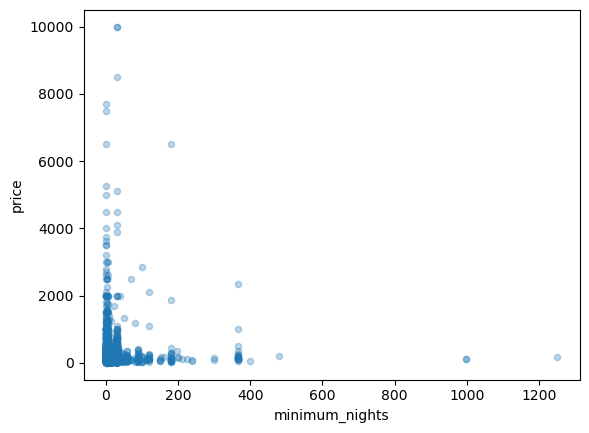

In [23]:
df.plot.scatter(x='minimum_nights', y='price', alpha=0.3)

3. What do you notice in the data? Look around and see what you can find.

> For example, there are missing values in a few columns and the column `last_review` is a date but it is in string format. Look also at the `price` column, and note the outliers. There are some zeros and some very high prices. After talking to your stakeholders, you decide to consider from a minimum of `$10` to a maximum of `$350` per night.

Using df.describe(), I noticed large gaps between the 75th percentile and the maximum values for price, minimum_nights, and calculated_host_listings_count, so I decided to investigate these variables further.

For calculated_host_listings_count, I found a particularly large increase between the 95th and 99th percentiles, from 14 to 232. I then examined the top 10 listings with the highest calculated_host_listings_count values to look for patterns in room_type, neighbourhood_group, neighbourhood, minimum_nights, and price. All 10 listings were located in Manhattan, had a room type of Entire home/apt, and were posted by the same host_id. Their prices varied considerably, ranging from 100 to 472.

I also examined the most frequently occurring host_id values in the dataset. The host with the most listings appeared 131 times, which did not align with the maximum calculated_host_listings_count value of 327. This suggests that calculated_host_listings_count does not represent the number of rows for a given host in this specific dataframe; instead, it reflects a count derived from a broader source or dataset.

I also created a scatter plot to examine the relationship between minimum_nights and price. The extreme values in both variables made the overall relationship difficult to interpret. However, listings with minimum_nights above 1,000 appeared to have relatively low prices.

Since the project instructions specify that the price should range from 10 to 350 and that last_review should use a date format, I will make those required corrections while keeping the other EDA observations in mind during later preprocessing and modeling steps.

4. Fix some of the little problems we have found in the data with the following code:

In [24]:
# Drop outliers
min_price = 10
max_price = 350
idx = df['price'].between(min_price, max_price)
df = df[idx].copy()
# Convert last_review to datetime
df['last_review'] = pd.to_datetime(df['last_review'])

Note how we did not impute missing values. We will do that in the inference pipeline, so we will be able to handle missing values also in production.

5. Check with df.info() that all obvious problems have been solved

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19001 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              19001 non-null  int64         
 1   name                            18994 non-null  object        
 2   host_id                         19001 non-null  int64         
 3   host_name                       18993 non-null  object        
 4   neighbourhood_group             19001 non-null  object        
 5   neighbourhood                   19001 non-null  object        
 6   latitude                        19001 non-null  float64       
 7   longitude                       19001 non-null  float64       
 8   room_type                       19001 non-null  object        
 9   price                           19001 non-null  int64         
 10  minimum_nights                  19001 non-null  int64         
 11  number_

6. Terminate the run by running `run.finish()`

In [26]:
run.finish()

7. Save the notebook.